In [4]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# 1️⃣ Load dataset and clean
# ----------------------
df = pd.read_csv(r"C:\Users\ammar\OneDrive\Desktop\online_retail_II.csv", encoding="ISO-8859-1")

# Remove missing / invalid rows
df.dropna(subset=["Invoice", "StockCode", "Description", "Quantity", "Price"], inplace=True)
df = df[df["Quantity"] != 0]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df = df.dropna(subset=["InvoiceDate"])

# Create Revenue column
df["Revenue"] = df["Quantity"] * df["Price"]


In [6]:
# 2️⃣ Import into SQLite
# ----------------------
conn = sqlite3.connect("retail.db")
df.to_sql("online_retail", conn, if_exists="replace", index=False)

1044203

In [7]:
# 3️⃣ Calculate Profit / Revenue by Product (SQL)
# ----------------------
query = """
SELECT 
    Description AS Product,
    SUM(Quantity * Price) AS Revenue,
    COUNT(DISTINCT Invoice) AS NumInvoices
FROM online_retail
GROUP BY Description
ORDER BY Revenue DESC
LIMIT 10;
"""

top_products_sql = pd.read_sql_query(query, conn)
print("\n=== TOP PRODUCTS BY REVENUE (SQL) ===")
print(top_products_sql)



=== TOP PRODUCTS BY REVENUE (SQL) ===
                               Product    Revenue  NumInvoices
0             REGENCY CAKESTAND 3 TIER  322643.15         4216
1                       DOTCOM POSTAGE  304979.93         1410
2   WHITE HANGING HEART T-LIGHT HOLDER  255777.96         5552
3              JUMBO BAG RED RETROSPOT  147803.47         3302
4                        PARTY BUNTING  147361.56         2680
5        ASSORTED COLOUR BIRD ORNAMENT  130242.39         2797
6      PAPER CHAIN KIT 50'S CHRISTMAS   116439.35         1958
7                              POSTAGE  110219.21         2037
8                        CHILLI LIGHTS   83145.65         1137
9  ROTATING SILVER ANGELS T-LIGHT HLDR   71853.48          730


In [8]:
# 4️⃣ Correlation between Inventory Days and Profitability
# ----------------------
# Simulate inventory days (replace with actual if available)
inventory_days = pd.DataFrame({
    "Description": df["Description"].unique(),
    "InventoryDays": np.random.randint(5, 90, size=df["Description"].nunique())
})

# Total revenue per product
profitability = df.groupby("Description")["Revenue"].sum().reset_index()

# Merge inventory days
analysis = pd.merge(profitability, inventory_days, on="Description")

# Correlation
corr = analysis["Revenue"].corr(analysis["InventoryDays"])
print("\nCorrelation between Revenue and Inventory Days:", corr)


Correlation between Revenue and Inventory Days: -0.009479733562337438



=== TOP 10 PROFIT-DRAINING PRODUCTS ===
                              Description     Revenue
236                            AMAZON FEE -231340.620
380                       Adjust bad debt -147614.080
2988                               Manual  -82847.840
840                          Bank Charges  -33508.669
1507                             Discount  -13484.540
1238                      CRUK Commission   -6832.990
4161                              SAMPLES   -6065.800
7                            Bank Charges   -2068.960
382   Adjustment by Peter on 24/05/2010 1    -731.050
4576                 SILVER CHERRY LIGHTS    -611.280


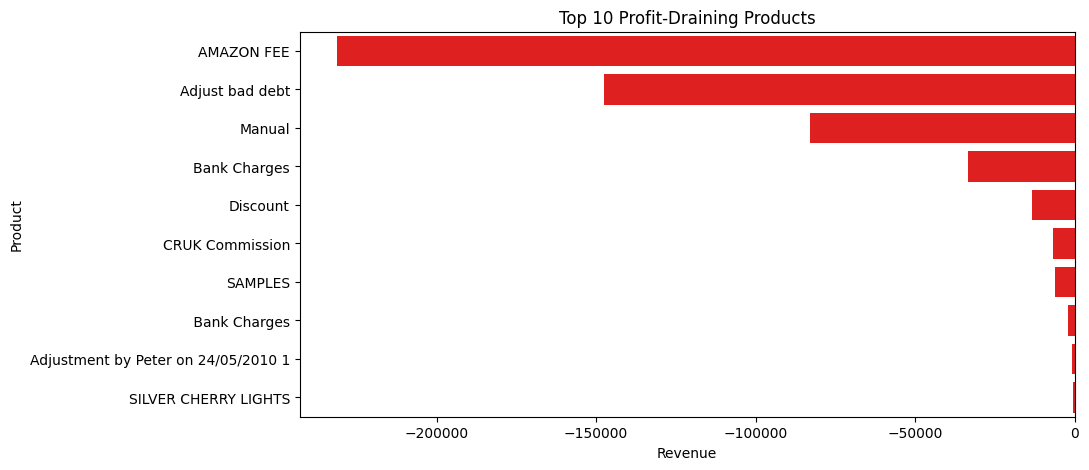

In [9]:
# 5️⃣ Profit-draining products
# ----------------------
profitability_sorted = profitability.sort_values(by="Revenue", ascending=True)
loss_making = profitability_sorted.head(10)

print("\n=== TOP 10 PROFIT-DRAINING PRODUCTS ===")
print(loss_making)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x="Revenue", y="Description", data=loss_making, color="red")
plt.title("Top 10 Profit-Draining Products")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()



=== TOP 10 FAST MOVING PRODUCTS ===
                             Description  Quantity
5384   WORLD WAR 2 GLIDERS ASSTD DESIGNS    107472
5262  WHITE HANGING HEART T-LIGHT HOLDER     92436
326        ASSORTED COLOUR BIRD ORNAMENT     80608
2505             JUMBO BAG RED RETROSPOT     77641
799                  BROCADE RING PURSE      70423
3201  PACK OF 60 PINK PAISLEY CAKE CASES     56366
168          60 TEATIME FAIRY CAKE CASES     54271
4702                SMALL POPCORN HOLDER     49616
3204     PACK OF 72 RETROSPOT CAKE CASES     49030
3203    PACK OF 72 RETRO SPOT CAKE CASES     46106

=== TOP 10 SLOW MOVING PRODUCTS ===
                       Description  Quantity
5505           Zebra invcing error     -9000
3738  Printing smudges/thrown away     -9058
2221                    Given away    -10200
5525                         check    -11948
5566                    ebay sales    -13630
5044        Unsaleable, destroyed.    -15644
5596                       missing    -16129
5610 

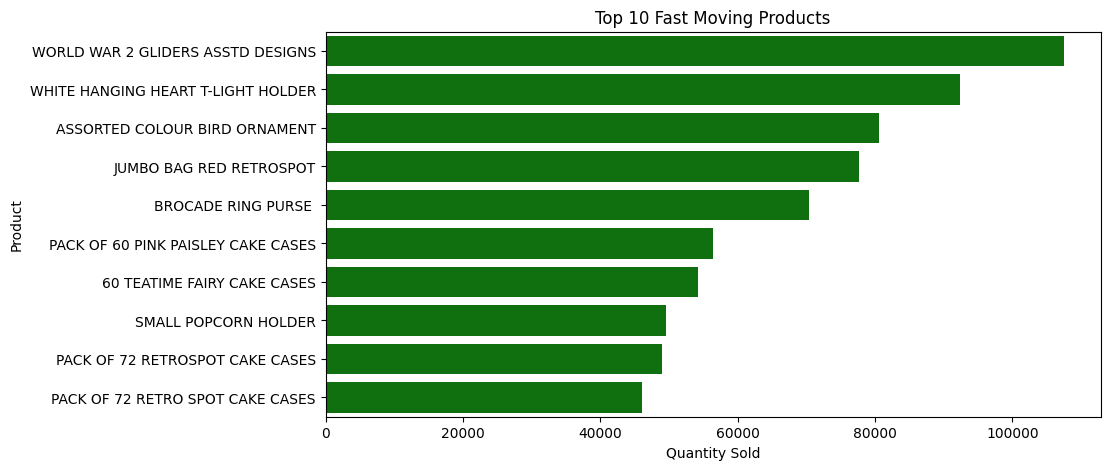

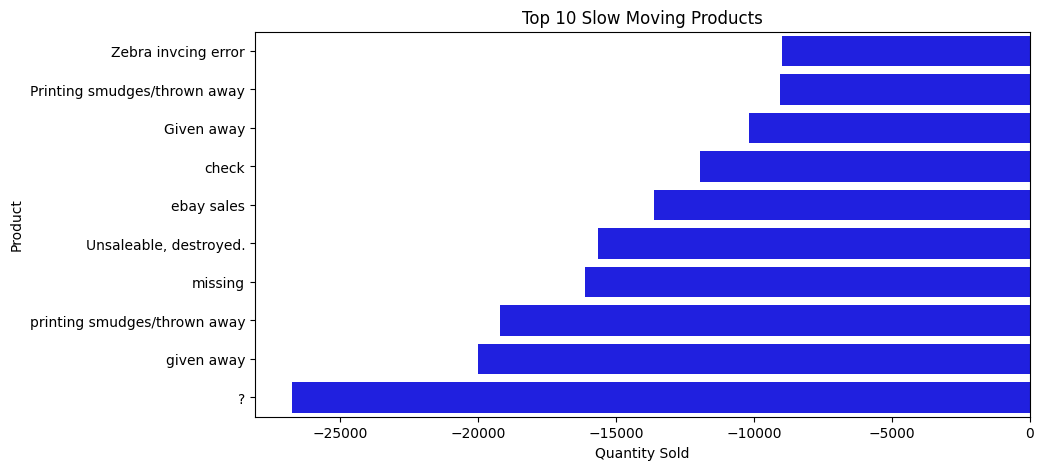

In [10]:
# 6️⃣ Inventory turnover
# ----------------------
inventory_turnover = df.groupby("Description")["Quantity"].sum().reset_index()
inventory_turnover = inventory_turnover.sort_values(by="Quantity", ascending=False)

fast_movers = inventory_turnover.head(10)
slow_movers = inventory_turnover.tail(10)

print("\n=== TOP 10 FAST MOVING PRODUCTS ===")
print(fast_movers)
print("\n=== TOP 10 SLOW MOVING PRODUCTS ===")
print(slow_movers)

# Plots
plt.figure(figsize=(10,5))
sns.barplot(x="Quantity", y="Description", data=fast_movers, color="green")
plt.title("Top 10 Fast Moving Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x="Quantity", y="Description", data=slow_movers, color="blue")
plt.title("Top 10 Slow Moving Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()


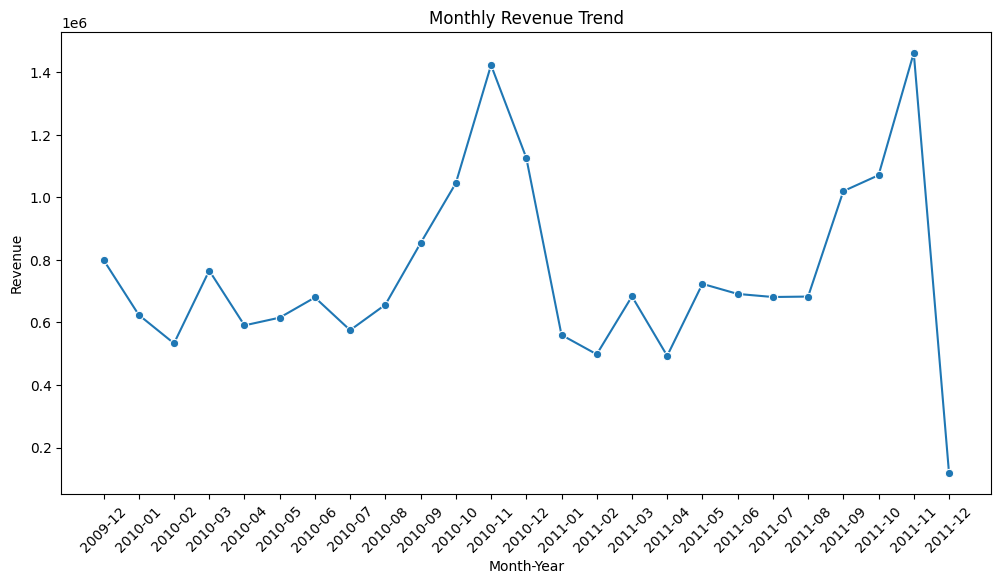

In [11]:
# 7️⃣ Overall monthly revenue trend
# ----------------------
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
monthly_revenue = df.groupby("YearMonth")["Revenue"].sum().reset_index()
monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].astype(str)

plt.figure(figsize=(12,6))
sns.lineplot(x="YearMonth", y="Revenue", data=monthly_revenue, marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month-Year")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


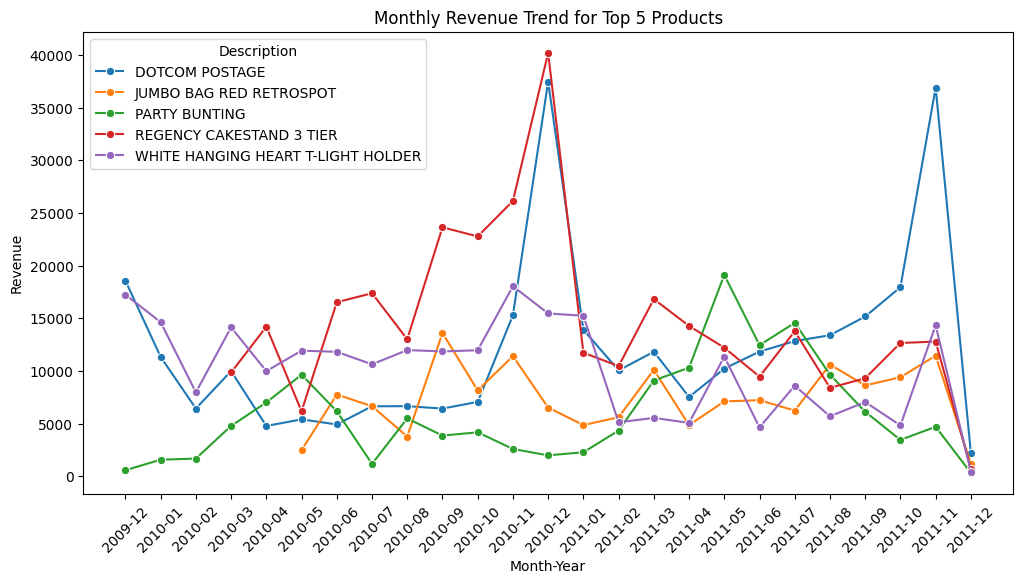

In [12]:
# 8️⃣ Top 5 products monthly seasonality
# ----------------------
product_monthly = df.groupby(["Description", "YearMonth"])["Revenue"].sum().reset_index()
product_monthly["YearMonth"] = product_monthly["YearMonth"].astype(str)

# Top 5 products by total revenue
top_5_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(5).index
product_monthly_top5 = product_monthly[product_monthly["Description"].isin(top_5_products)]

plt.figure(figsize=(12,6))
sns.lineplot(x="YearMonth", y="Revenue", hue="Description", data=product_monthly_top5, marker="o")
plt.title("Monthly Revenue Trend for Top 5 Products")
plt.xlabel("Month-Year")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [16]:
import pandas as pd
import numpy as np

# ----------------------
# Load and clean dataset
# ----------------------
df = pd.read_csv(r"C:\Users\ammar\OneDrive\Desktop\online_retail_II.csv", encoding="ISO-8859-1")
df.dropna(subset=["Invoice", "StockCode", "Description", "Quantity", "Price"], inplace=True)
df = df[df["Quantity"] != 0]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df = df.dropna(subset=["InvoiceDate"])

# Revenue column
df["Revenue"] = df["Quantity"] * df["Price"]

# Month-Year column
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

# ----------------------
# Product-level metrics
# ----------------------
# Total revenue per product
product_revenue = df.groupby("Description")["Revenue"].sum().reset_index().rename(columns={"Revenue":"TotalRevenue"})

# Low-performing products (bottom 20%)
threshold = product_revenue["TotalRevenue"].quantile(0.2)
product_revenue["LowPerfFlag"] = product_revenue["TotalRevenue"] <= threshold

# Merge back to main df
df = df.merge(product_revenue, on="Description", how="left")

# ----------------------
# Inventory info (simulated)
# ----------------------
inventory_days = pd.DataFrame({
    "Description": df["Description"].unique(),
    "InventoryDays": np.random.randint(5, 90, size=df["Description"].nunique())
})
df = df.merge(inventory_days, on="Description", how="left")

# ----------------------
# Profit-draining / slow-moving flags
# ----------------------
# Profit-draining: negative or low revenue
df["ProfitDrainingFlag"] = df["Revenue"] < 0

# Slow-moving: bottom 10% by quantity sold per product
quantity_per_product = df.groupby("Description")["Quantity"].sum().reset_index()
slow_threshold = quantity_per_product["Quantity"].quantile(0.1)
quantity_per_product["SlowMoverFlag"] = quantity_per_product["Quantity"] <= slow_threshold
df = df.merge(quantity_per_product[["Description", "SlowMoverFlag"]], on="Description", how="left")

# ----------------------
# Optional: Season column
# ----------------------
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["InvoiceDate"].dt.month.apply(get_season)

# ----------------------
# Export unified CSV
# ----------------------
df.to_csv("online_retail_unified_for_tableau.csv", index=False)
print("✅ Unified CSV ready for Tableau: online_retail_unified_for_tableau.csv")


✅ Unified CSV ready for Tableau: online_retail_unified_for_tableau.csv
